In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("06-2025.csv")

In [3]:
df.head()

,Record ID,Activity date,Call direction,Call duration,hs_call_outcome,Activity assigned to
0,80548049535,2025-06-01 16:44,Outbound,00:00:00,NaN,Kevin Nuesi
1,80547821455,2025-06-01 16:45,Outbound,00:00:00,NaN,Kevin Nuesi
2,80550594447,2025-06-01 20:15,Inbound,00:00:00,NaN,NaN
3,80566407069,2025-06-02 09:22,NaN,NaN,NaN,Robin Stoehr
4,80569306473,2025-06-02 09:52,NaN,NaN,NaN,Robin Stoehr


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10157 entries, 0 to 10156
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Record ID             10157 non-null  int64  
 1   Activity date         10157 non-null  object 
 2   Call direction        9122 non-null   object 
 3   Call duration         9183 non-null   object 
 4   hs_call_outcome       0 non-null      float64
 5   Activity assigned to  9431 non-null   object 
dtypes: float64(1), int64(1), object(4)
memory usage: 476.2+ KB


In [5]:
df1 = df.drop(columns = ['hs_call_outcome', 'Record ID'])

In [6]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10157 entries, 0 to 10156
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Activity date         10157 non-null  object
 1   Call direction        9122 non-null   object
 2   Call duration         9183 non-null   object
 3   Activity assigned to  9431 non-null   object
dtypes: object(4)
memory usage: 317.5+ KB


In [7]:
df1['Activity date'] = pd.to_datetime(
    df1['Activity date'],
    format = "%Y-%m-%d %H:%M",
    errors = 'coerce'
) 

In [8]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10157 entries, 0 to 10156
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Activity date         10157 non-null  datetime64[ns]
 1   Call direction        9122 non-null   object        
 2   Call duration         9183 non-null   object        
 3   Activity assigned to  9431 non-null   object        
dtypes: datetime64[ns](1), object(3)
memory usage: 317.5+ KB


# Call Count per day

In [9]:
df2 = df1.copy()

In [10]:
df2['date'] = df2['Activity date'].dt.date

In [11]:
df2.head()

,Activity date,Call direction,Call duration,Activity assigned to,date
0,2025-06-01 16:44:00,Outbound,00:00:00,Kevin Nuesi,2025-06-01
1,2025-06-01 16:45:00,Outbound,00:00:00,Kevin Nuesi,2025-06-01
2,2025-06-01 20:15:00,Inbound,00:00:00,NaN,2025-06-01
3,2025-06-02 09:22:00,NaN,NaN,Robin Stoehr,2025-06-02
4,2025-06-02 09:52:00,NaN,NaN,Robin Stoehr,2025-06-02


In [12]:
daily_calls = (
    df2.groupby(df2['Activity date'].dt.date)
    .size()
    .reset_index(name='call_count')
    .rename(columns={'Activity date': 'date'})
)

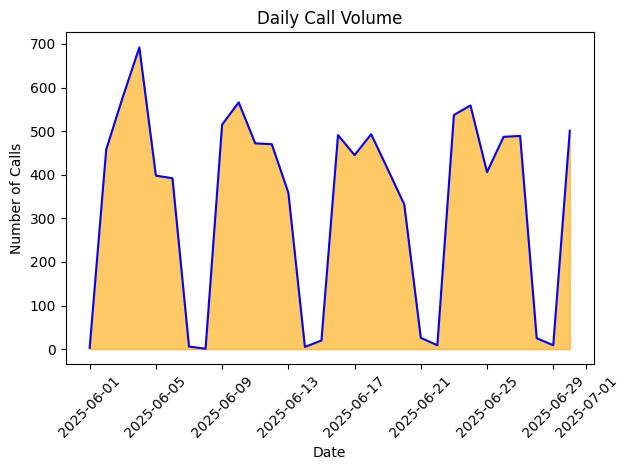

In [13]:
plt.figure()
plt.plot(daily_calls['date'], daily_calls['call_count'],color='blue')

plt.fill_between(daily_calls['date'], daily_calls['call_count'], color='orange', alpha=0.6)

plt.title("Daily Call Volume")
plt.xlabel("Date")
plt.ylabel("Number of Calls")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Count of Call in Weekdays

In [14]:
df1['day'] = df1['Activity date'].dt.day_name()

In [15]:
df1.head()

,Activity date,Call direction,Call duration,Activity assigned to,day
0,2025-06-01 16:44:00,Outbound,00:00:00,Kevin Nuesi,Sunday
1,2025-06-01 16:45:00,Outbound,00:00:00,Kevin Nuesi,Sunday
2,2025-06-01 20:15:00,Inbound,00:00:00,NaN,Sunday
3,2025-06-02 09:22:00,NaN,NaN,Robin Stoehr,Monday
4,2025-06-02 09:52:00,NaN,NaN,Robin Stoehr,Monday


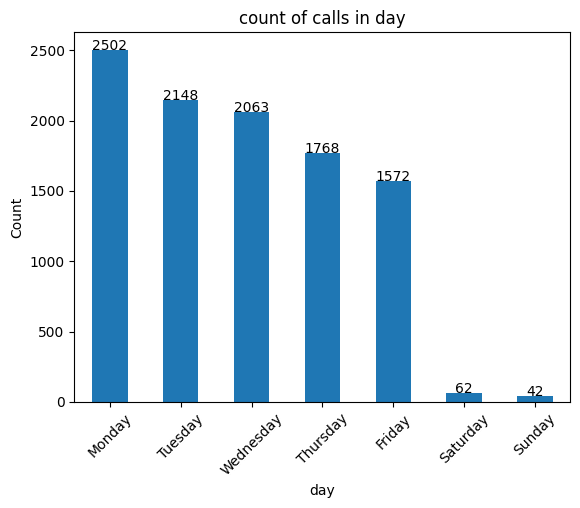

In [16]:
day_Counts = df1["day"].value_counts()
day_Counts.plot(kind='bar')
ax= day_Counts.plot(kind='bar')

for i,v in enumerate(day_Counts):
    ax.text(i, v+1, str(v), ha="center")

plt.title("count of calls in day")
plt.xlabel("day")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Inbound VS Outbound

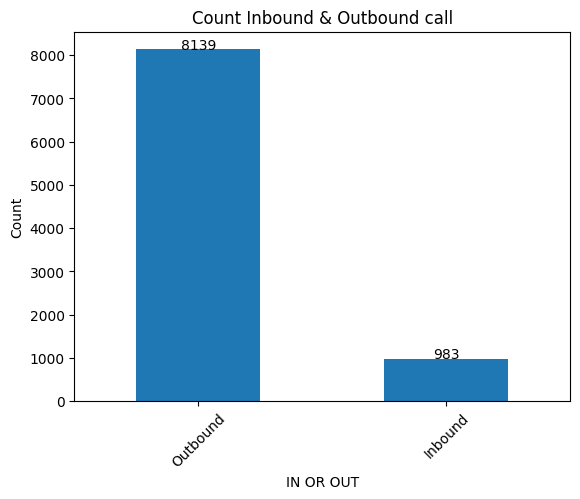

In [17]:
IN_OUT_COUNT = df1['Call direction'].value_counts()
IN_OUT_COUNT.plot(kind='bar')
ax = IN_OUT_COUNT.plot(kind='bar')

for i,v in enumerate(IN_OUT_COUNT):
    ax.text(i, v+1, str(v), ha="center")

plt.title("Count Inbound & Outbound call")
plt.xlabel("IN OR OUT")
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# Count 00 Duration for Bound

In [18]:
N_B = df1[(df1['Call duration'] == "00:00:00")]

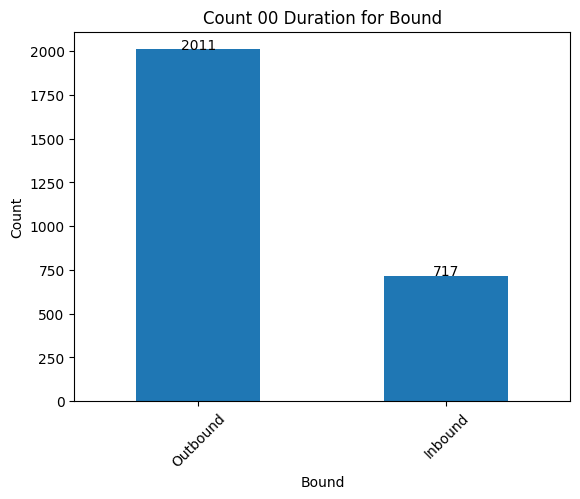

In [19]:
N_B_Counts = N_B['Call direction'].value_counts()
N_B_Counts.plot(kind="bar")
ax = N_B_Counts.plot(kind="bar")

for i,v in enumerate(N_B_Counts):
    ax.text(i, v+1, str(v), ha="center")

plt.title("Count 00 Duration for Bound")
plt.xlabel("Bound")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Call duration NULL but have Call direction

In [20]:
df1[(df1['Call duration'].isnull()) & (df1['Call direction'].notnull())]

,Activity date,Call direction,Call duration,Activity assigned to,day
1964,2025-06-05 15:30:00,Outbound,NaN,Jinky Rance,Thursday
3192,2025-06-10 13:58:00,Outbound,NaN,Robin Stoehr,Tuesday
4229,2025-06-12 13:59:00,Outbound,NaN,Keith Antonio,Thursday
6424,2025-06-19 12:03:00,Inbound,NaN,Robin Stoehr,Thursday
6935,2025-06-20 14:30:00,Outbound,NaN,Christian Banks,Friday
6937,2025-06-20 14:32:00,Outbound,NaN,Christian Banks,Friday
6939,2025-06-20 14:34:00,Outbound,NaN,Christian Banks,Friday
6943,2025-06-20 14:44:00,Outbound,NaN,Christian Banks,Friday
7368,2025-06-23 15:05:00,Outbound,NaN,Robin Stoehr,Monday
9832,2025-06-30 15:31:00,Outbound,NaN,Christian Banks,Monday


In [21]:
df4 = df1.copy()

In [22]:
df4['Call duration'] = (
    pd.to_timedelta(df4['Call duration'], errors = 'coerce')
    .dt.total_seconds()/60
)

In [23]:
(df4['Call duration'] == 0).sum()

2728

In [24]:
df4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10157 entries, 0 to 10156
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Activity date         10157 non-null  datetime64[ns]
 1   Call direction        9122 non-null   object        
 2   Call duration         9183 non-null   float64       
 3   Activity assigned to  9431 non-null   object        
 4   day                   10157 non-null  object        
dtypes: datetime64[ns](1), float64(1), object(3)
memory usage: 396.9+ KB


In [25]:
df4['Call duration'] = df4['Call duration'].fillna(0)

In [26]:
df4 = df4.dropna(subset = ['Call direction'])

In [27]:
(df4['Call duration'] == 0).sum()

2738

In [28]:
df4.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9122 entries, 0 to 10156
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Activity date         9122 non-null   datetime64[ns]
 1   Call direction        9122 non-null   object        
 2   Call duration         9122 non-null   float64       
 3   Activity assigned to  8412 non-null   object        
 4   day                   9122 non-null   object        
dtypes: datetime64[ns](1), float64(1), object(3)
memory usage: 427.6+ KB


# Working Call Assigner

In [29]:
df1['Activity assigned to'].nunique()

27

In [30]:
df1['Activity assigned to'].unique()

array(['Kevin Nuesi', nan, 'Robin Stoehr', 'Cameron Dudley',
       'Christian Banks', 'David Valdez', 'Cameron Byrd',
       'Boston Hoppman', 'Keith Antonio', 'Tyler Smith', 'Jinky Rance',
       'Sam Steindorf', 'Jerome Joyce', 'Abhi C', 'Garrett Evans',
       'Chrystel Manabat', 'Tyler Jury', 'Jon Karimov', 'Blake Roudebush',
       'David Banister', 'Brittany Digiulio', 'Paol Guzman',
       'Adonis Baybayan', 'Oliver Martin', 'Nick Rothacher',
       'Bill Goodwin', 'Juan Calo', 'Jibran Ahmad'], dtype=object)

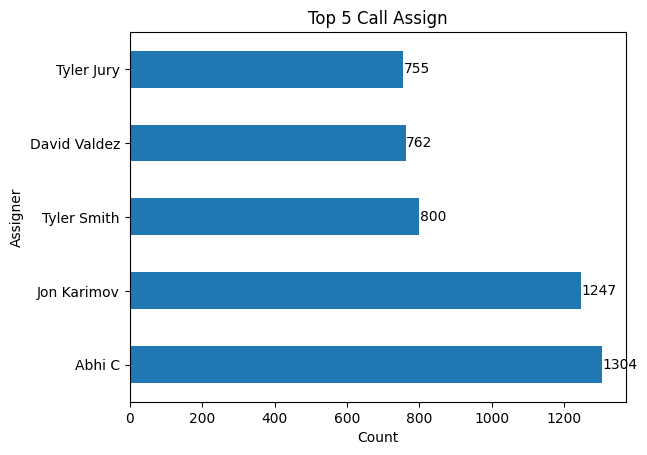

In [31]:
ASSI_COUNT = df1['Activity assigned to'].value_counts().head(5)

ax = ASSI_COUNT.plot(kind='barh')

for i,v in enumerate(ASSI_COUNT):
    ax.text(v+1, i, str(v), va="center")

plt.title("Top 5 Call Assign")
plt.xlabel("Count")
plt.ylabel("Assigner")
plt.show()

# Max Call Duration

In [32]:
df4['Call duration'].max()

75.95

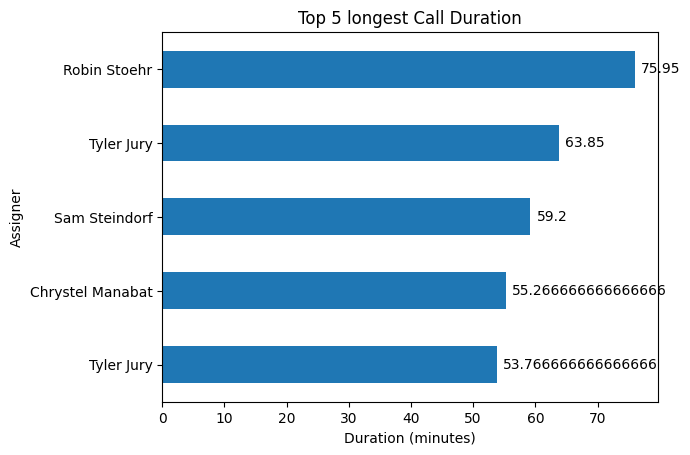

In [33]:
top5 = df4.nlargest(5, "Call duration")

ax = top5.set_index('Activity assigned to')['Call duration'].sort_values().plot(kind="barh")

for i, v in enumerate(top5["Call duration"].sort_values()):
    ax.text(v+1, i, str(v), va="center")

plt.title("Top 5 longest Call Duration")
plt.xlabel("Duration (minutes)")
plt.ylabel("Assigner")
plt.show()

# Only Weekdays Call Volume

In [34]:
df3 = df1.copy()

In [35]:
df3 = df3[~df3['day'].isin(['Saturday', 'Sunday'])]

In [36]:
df3['day'].unique()

array(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday'],
      dtype=object)

In [37]:
week_day_calls=(
    df3.groupby(df3['Activity date'].dt.date)
    .size()
    .reset_index(name='call_count')
    .rename(columns={'Activity date': 'date'})
)

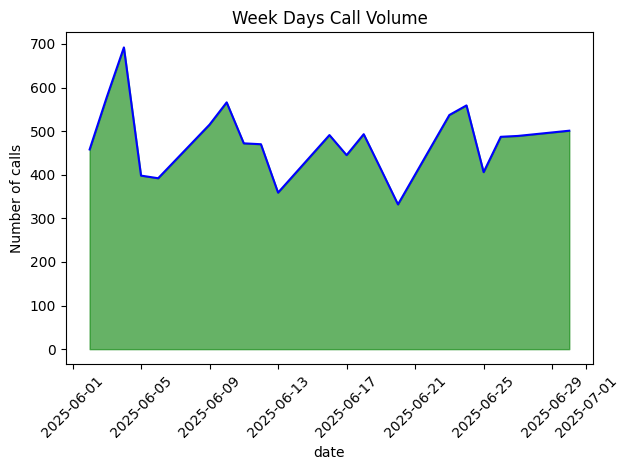

In [38]:
plt.figure()
plt.plot(week_day_calls['date'], week_day_calls['call_count'], color='blue')

plt.fill_between(week_day_calls['date'], week_day_calls['call_count'],color='green', alpha=0.6)

plt.title("Week Days Call Volume")
plt.xlabel("date")
plt.ylabel("Number of calls")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# WEEKEND TIME DURATION

In [39]:
df5=df4.copy()

In [40]:
df5 = df5[~df5['day'].isin(['Monday', 'Thursday', 'Friday', 'Wednesday', 'Tuesday'])]

In [41]:
df5.head()

,Activity date,Call direction,Call duration,Activity assigned to,day
0,2025-06-01 16:44:00,Outbound,0.000000,Kevin Nuesi,Sunday
1,2025-06-01 16:45:00,Outbound,0.000000,Kevin Nuesi,Sunday
2,2025-06-01 20:15:00,Inbound,0.000000,NaN,Sunday
2521,2025-06-07 09:07:00,Outbound,0.316667,Blake Roudebush,Saturday
2522,2025-06-07 10:18:00,Inbound,0.000000,NaN,Saturday


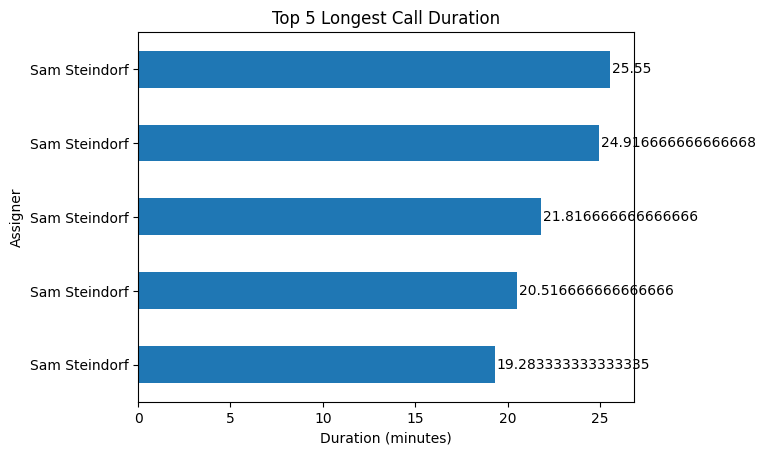

In [42]:
top5 = df5.nlargest(5, "Call duration")

ax = top5.set_index("Activity assigned to")["Call duration"].sort_values().plot(kind="barh")

for i, v in enumerate(top5["Call duration"].sort_values()):
    ax.text(v + 0.1, i, str(v), va="center")

plt.title("Top 5 Longest Call Duration")
plt.xlabel("Duration (minutes)")
plt.ylabel("Assigner")
plt.show()

# Top 5 Weekend Call Assigner

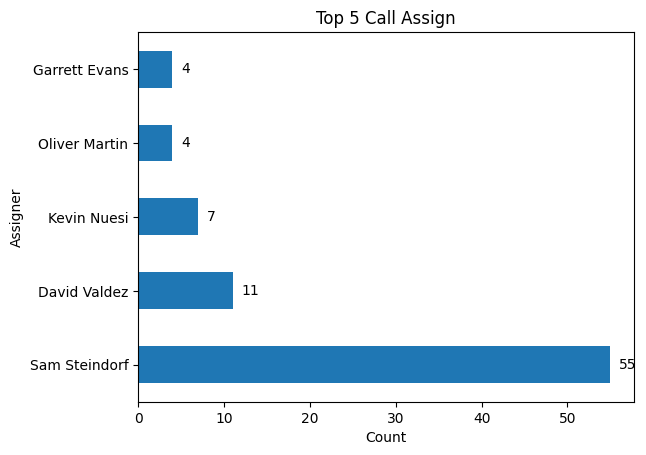

In [43]:
ASSI_COUNT = df5['Activity assigned to'].value_counts().head(5)

ax = ASSI_COUNT.plot(kind='barh')

for i,v in enumerate(ASSI_COUNT):
    ax.text(v+1, i, str(v), va="center")

plt.title("Top 5 Call Assign")
plt.xlabel("Count")
plt.ylabel("Assigner")
plt.show()

# Average Call Duration

In [44]:
df4["Call duration"].mean()

2.293387780457502

In [45]:
df4["Call duration"].median()

0.08333333333333333

# Without Call Assigner Calls

In [46]:
df6 = df3.copy()

In [47]:
df6['month'] = df6['Activity date'].dt.month_name()

In [48]:
no_assigner_calls = df6[df6["Activity assigned to"].isna()]

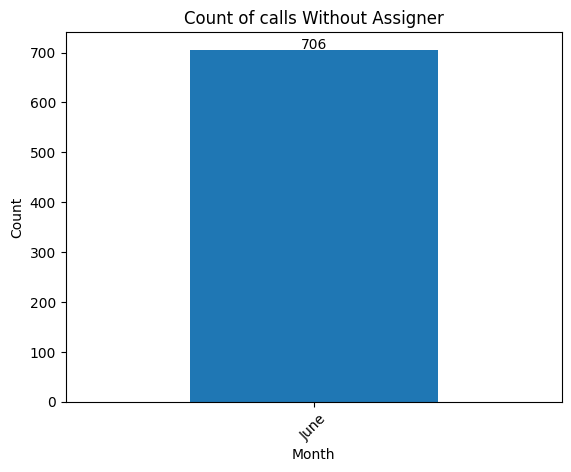

In [49]:
month_counts = no_assigner_calls["month"].value_counts()
month_counts.plot(kind="bar")
ax = month_counts.plot(kind="bar")

for i, v in enumerate(month_counts):
    ax.text(i, v + 1, str(v), ha="center")

plt.title("Count of calls Without Assigner")
plt.xlabel("Month")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Top 5 Peak Call Date

In [50]:
daily_calls = df.groupby(df2["Activity date"].dt.date).size()

In [51]:
top5 = daily_calls.sort_values(ascending=False).head(5)

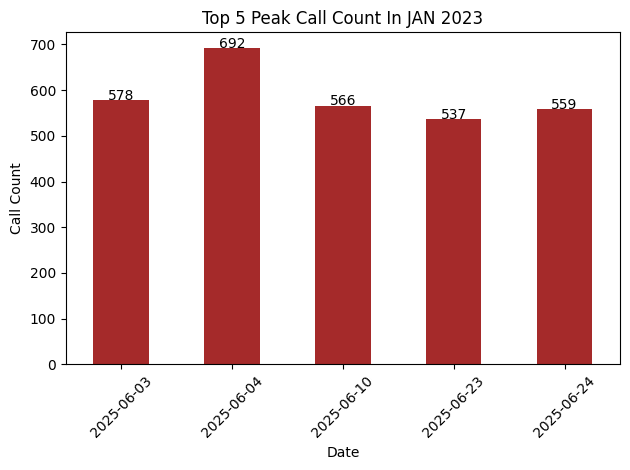

In [52]:
ax = top5.sort_index().plot(kind="bar", color="brown")

for i, v in enumerate(top5.sort_index()):
    ax.text(i, v + 0.5, str(v), ha="center", fontsize=10)
    
plt.title("Top 5 Peak Call Count In JAN 2023")
plt.xlabel("Date")
plt.ylabel("Call Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()